# Direct RPKM — all time points and chromatin states

Mean RPKM profiles for ATAC, H3K9me3 and H3K27me3. Real and simulated profiles are calculated and plotted separately. Real/sim and baseline-normalized profiles are also produced.

In [14]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = Path('/cta/users/guneyn23/peak_center_20kb')
OUTPUT_DIR = Path('/cta/users/guneyn23/relative_repair/direct_rpkm_all_timepoints')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

REGION_DIRS = {
    'ATAC': BASE / 'ATAC_rpkm/noUV_atac_damage_all',
    'H3K9me3': BASE / 'close_rpkm/H3K9me3',
    'H3K27me3': BASE / 'close_rpkm/H3K27me3',
}
REGIONS = list(REGION_DIRS)
DAMAGES = ['CPD', '64']
TIME_POINTS = ['1m', '15m', '30m', '1h', '4h', '8h']
NUMBER_OF_WINDOWS = 400

SAMPLE_STEMS = {
    ('CPD', '1m'): 'R3Hela_1mCPD_CGATGT_S6_hg38_primary_assembly_DS',
    ('CPD', '15m'): 'R3Hela_15mCPD_TAGCTT_S2_hg38_primary_assembly_DS',
    ('CPD', '30m'): 'R3Hela_30mCPD_GGCTAC_S8_hg38_primary_assembly_DS',
    ('CPD', '1h'): 'R3Hela_1hCPD_CTTGTA_S4_hg38_primary_assembly_DS',
    ('CPD', '4h'): 'R3Hela_4hCPD_AGTCAA_S10_hg38_primary_assembly_DS',
    ('CPD', '8h'): 'R3Hela_8hCPD_AGTTCC_S12_hg38_primary_assembly_DS',
    ('64', '15m'): 'R3Hela_15m64_TTAGGC_S1_hg38_primary_assembly_DS',
    ('64', '30m'): 'R3Hela_30m64_TGACCA_S7_hg38_primary_assembly_DS',
    ('64', '1h'): 'R3Hela_1h64_ACAGTG_S3_hg38_primary_assembly_DS',
    ('64', '4h'): 'R3Hela_4h64_GCCAAT_S9_hg38_primary_assembly_DS',
    ('64', '8h'): 'R3Hela_8h64_CAGATC_S11_hg38_primary_assembly_DS',
}

ONE_MIN_FILES = {
    ('ATAC', 'CPD', 'real'): Path('/cta/users/guneyn23/rpkm_1m/CPD_rpkm/atac_rpkm/real_damage_rpkm.bed'),
    ('ATAC', 'CPD', 'sim'): Path('/cta/users/guneyn23/rpkm_1m/CPD_rpkm/atac_rpkm/sim_damage_rpkm.bed'),
    ('H3K9me3', 'CPD', 'real'): Path('/cta/users/guneyn23/rpkm_1m/CPD_rpkm/close_rpkm/H3k9me3_real_rpkm.bed'),
    ('H3K9me3', 'CPD', 'sim'): Path('/cta/users/guneyn23/rpkm_1m/CPD_rpkm/close_rpkm/H3k9me3_sim_rpkm.bed'),
    ('H3K27me3', 'CPD', 'real'): Path('/cta/users/guneyn23/rpkm_1m/CPD_rpkm/close_rpkm/H3k27me3_real_rpkm.bed'),
    ('H3K27me3', 'CPD', 'sim'): Path('/cta/users/guneyn23/rpkm_1m/CPD_rpkm/close_rpkm/H3k27me3_sim_rpkm.bed'),
    ('ATAC', '64', 'real'): Path('/cta/users/guneyn23/rpkm_1m/64_rpkm/ATAC_real_64_rpkm.bed'),
    ('ATAC', '64', 'sim'): Path('/cta/users/guneyn23/rpkm_1m/64_rpkm/ATAC_simulated_64_rpkm.bed'),
    ('H3K9me3', '64', 'real'): Path('/cta/users/guneyn23/rpkm_1m/64_rpkm/H3K9me3_real_64_rpkm.bed'),
    ('H3K9me3', '64', 'sim'): Path('/cta/users/guneyn23/rpkm_1m/64_rpkm/H3K9me3_simulated_64_rpkm.bed'),
    ('H3K27me3', '64', 'real'): Path('/cta/users/guneyn23/rpkm_1m/64_rpkm/H3K27me3_real_64_rpkm.bed'),
    ('H3K27me3', '64', 'sim'): Path('/cta/users/guneyn23/rpkm_1m/64_rpkm/H3K27me3_simulated_64_rpkm.bed'),
}

ONE_MIN_MEAN_FILES = {
    ('ATAC', 'CPD'): Path('/cta/users/guneyn23/rpkm_1m/CPD_rpkm/atac_rpkm/mean_rpkm_ratio.tsv'),
    ('H3K9me3', 'CPD'): Path('/cta/users/guneyn23/rpkm_1m/CPD_rpkm/close_rpkm/H3K9me3_mean_rpkm_ratio.tsv'),
    ('H3K27me3', 'CPD'): Path('/cta/users/guneyn23/rpkm_1m/CPD_rpkm/close_rpkm/H3K27me3_mean_rpkm_ratio.tsv'),
    ('ATAC', '64'): Path('/cta/users/guneyn23/rpkm_1m/64_rpkm/ATAC_mean_normalized_rpkm.tsv'),
    ('H3K9me3', '64'): Path('/cta/users/guneyn23/rpkm_1m/64_rpkm/H3K9me3_mean_normalized_rpkm.tsv'),
    ('H3K27me3', '64'): Path('/cta/users/guneyn23/rpkm_1m/64_rpkm/H3K27me3_mean_normalized_rpkm.tsv'),
}

COLORS = {
    '1m': '#56B4E9', '15m': '#0072B2', '30m': '#E69F00', '1h': '#009E73',
    '4h': '#D55E00', '8h': '#CC79A7',
}
TITLES = {'CPD': 'CPD', '64': '6-4PP'}

def rpkm_path(region, damage, time, kind):
    if time == '1m':
        return ONE_MIN_FILES[(region, damage, kind)]

    stem = SAMPLE_STEMS[(damage, time)]
    if region == 'ATAC':
        sim_label = '_sim' if kind == 'sim' else ''
        name = f'{stem}{sim_label}_noUV_ATAC_400windows_rpkm.bed'
    else:
        sim_label = '_sim' if kind == 'sim' else ''
        name = f'{stem}{sim_label}_{region}_400windows_rpkm.bed'
    return REGION_DIRS[region] / name

def existing_mean_path(region, damage, time):
    if time == '1m':
        return ONE_MIN_MEAN_FILES[(region, damage)]
    if region == 'ATAC':
        return OUTPUT_DIR / f'{damage}_{time}_mean_rpkm_ratio.tsv'
    return OUTPUT_DIR / f'{region}_{damage}_{time}_mean_rpkm_ratio.tsv'


## Calculate mean RPKM for every window

In [15]:
def mean_by_window(path):
    data = pd.read_csv(path, sep='\t', header=None)
    data['rpkm'] = pd.to_numeric(data.iloc[:, -1], errors='coerce')

    # Read the window number from names such as peak_25_173.
    peak_names = data.iloc[:, 3].astype(str)
    data['window'] = pd.to_numeric(
        peak_names.str.rsplit('_', n=1).str[-1], errors='coerce'
    )

    if data['window'].isna().any():
        raise ValueError(f'Window number could not be read from column 4: {path}')

    result = data.groupby('window', sort=True)['rpkm'].mean()
    if len(result) != NUMBER_OF_WINDOWS:
        raise ValueError(f'Expected 400 windows but found {len(result)}: {path}')
    return result

tables = []

for region in REGIONS:
    for damage in DAMAGES:
        for time in TIME_POINTS:
            saved_mean = existing_mean_path(region, damage, time)

            if saved_mean is not None:
                print(f'Loading existing mean: {region} {damage} {time}')
                table = pd.read_csv(saved_mean, sep='\t')
            else:
                print(f'Calculating missing mean: {region} {damage} {time}')
                mean_real = mean_by_window(rpkm_path(region, damage, time, 'real'))
                mean_sim = mean_by_window(rpkm_path(region, damage, time, 'sim'))
                table = pd.DataFrame({
                    'window': mean_real.index.astype(int),
                    'mean_real_rpkm': mean_real.to_numpy(),
                    'mean_sim_rpkm': mean_sim.reindex(mean_real.index).to_numpy(),
                })
                table['real_sim_ratio'] = (
                    table['mean_real_rpkm']
                    / table['mean_sim_rpkm'].replace(0, np.nan)
                )

            table = table.copy()
            table.insert(0, 'time', time)
            table.insert(0, 'damage', damage)
            table.insert(0, 'region', region)
            table['distance_kb'] = -10 + (table['window'] - 0.5) * (20 / NUMBER_OF_WINDOWS)
            tables.append(table)

summary = pd.concat(tables, ignore_index=True)
summary.to_csv(OUTPUT_DIR / 'all_regions_direct_rpkm_summary.tsv', sep='\t', index=False)
summary.head()


Loading existing mean: ATAC CPD 1m
Loading existing mean: ATAC CPD 15m
Loading existing mean: ATAC CPD 30m
Loading existing mean: ATAC CPD 1h
Loading existing mean: ATAC CPD 4h
Loading existing mean: ATAC CPD 8h
Loading existing mean: ATAC 64 1m
Loading existing mean: ATAC 64 15m
Loading existing mean: ATAC 64 30m
Loading existing mean: ATAC 64 1h
Loading existing mean: ATAC 64 4h
Loading existing mean: ATAC 64 8h
Loading existing mean: H3K9me3 CPD 1m
Loading existing mean: H3K9me3 CPD 15m
Loading existing mean: H3K9me3 CPD 30m
Loading existing mean: H3K9me3 CPD 1h
Loading existing mean: H3K9me3 CPD 4h
Loading existing mean: H3K9me3 CPD 8h
Loading existing mean: H3K9me3 64 1m
Loading existing mean: H3K9me3 64 15m
Loading existing mean: H3K9me3 64 30m
Loading existing mean: H3K9me3 64 1h
Loading existing mean: H3K9me3 64 4h
Loading existing mean: H3K9me3 64 8h
Loading existing mean: H3K27me3 CPD 1m
Loading existing mean: H3K27me3 CPD 15m
Loading existing mean: H3K27me3 CPD 30m
Loading e

,region,damage,time,window,mean_real_rpkm,mean_sim_rpkm,real_sim_ratio,distance_kb
0,ATAC,CPD,1m,1,0.327125,0.316126,1.034793,-9.975
1,ATAC,CPD,1m,2,0.328556,0.315857,1.040207,-9.925
2,ATAC,CPD,1m,3,0.327433,0.317173,1.032348,-9.875
3,ATAC,CPD,1m,4,0.328365,0.315980,1.039197,-9.825
4,ATAC,CPD,1m,5,0.327099,0.314150,1.041219,-9.775


## Real and simulated mean RPKM separately

Every real and simulated panel uses the same global y-axis limits.

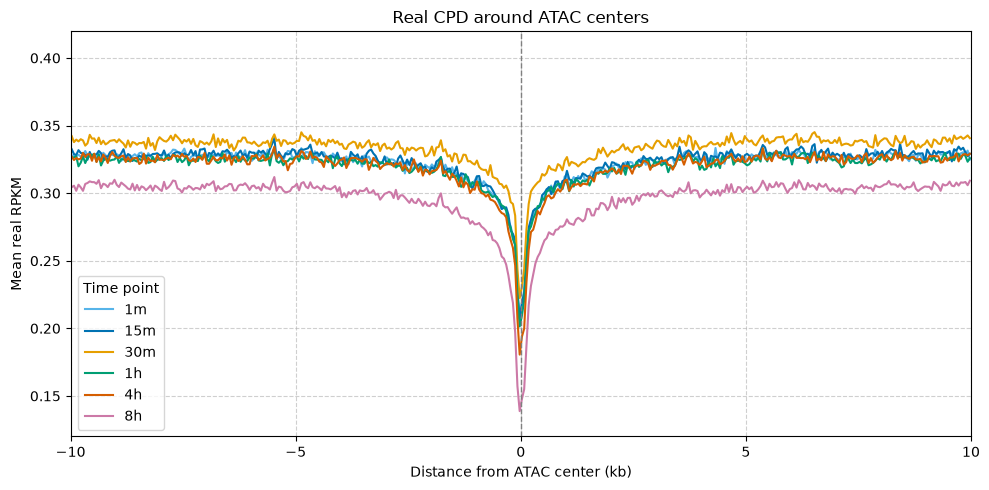

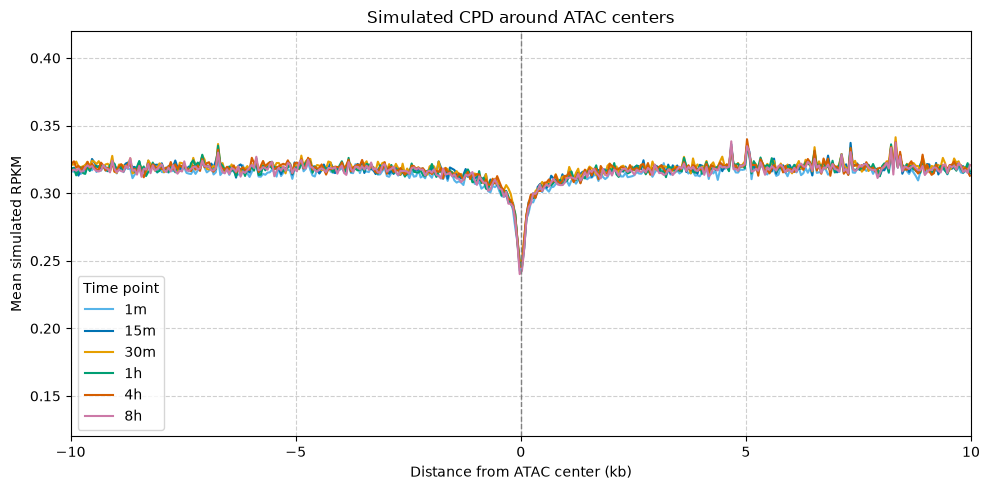

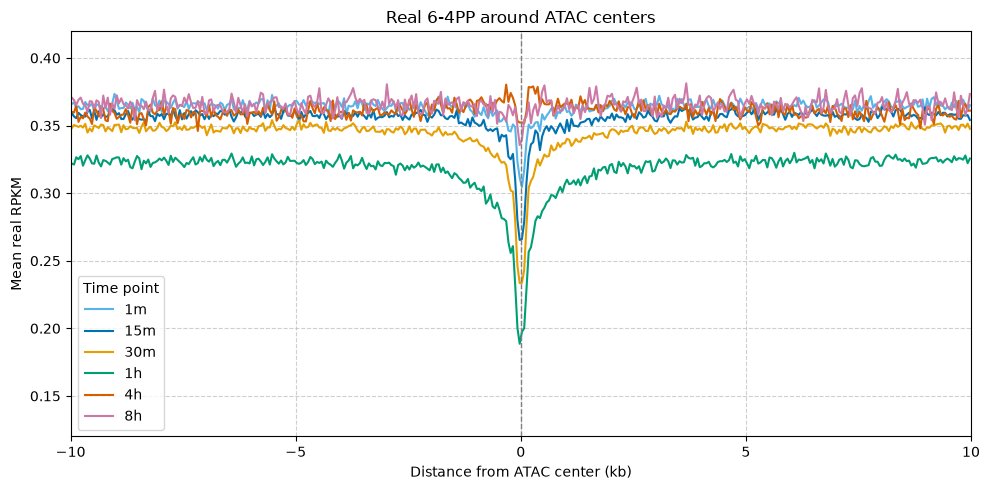

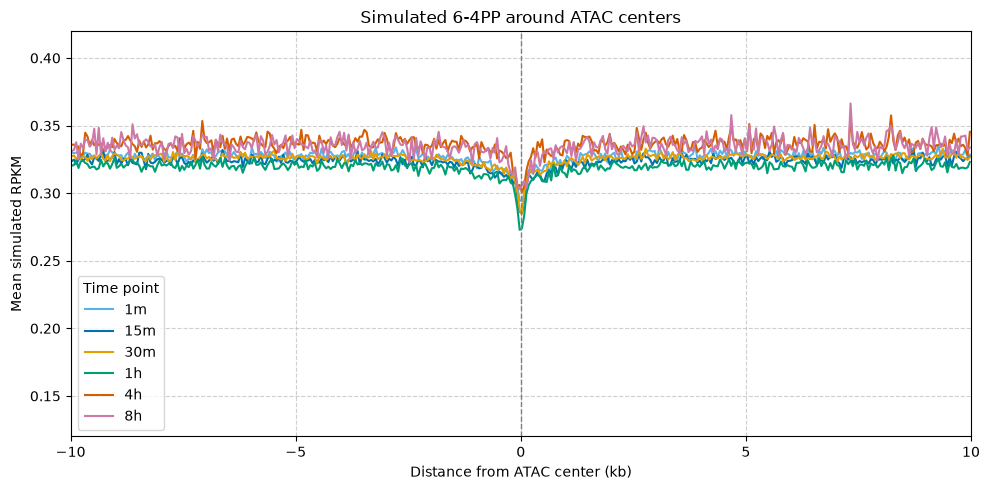

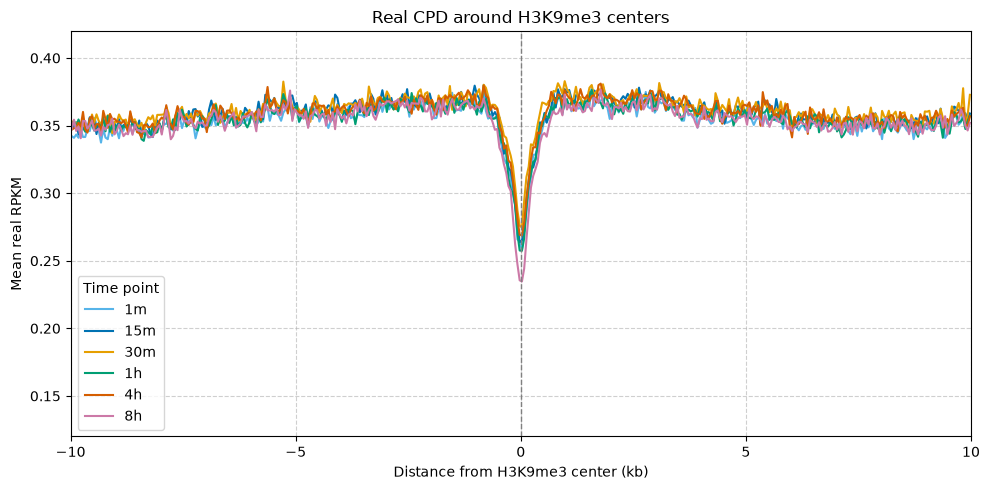

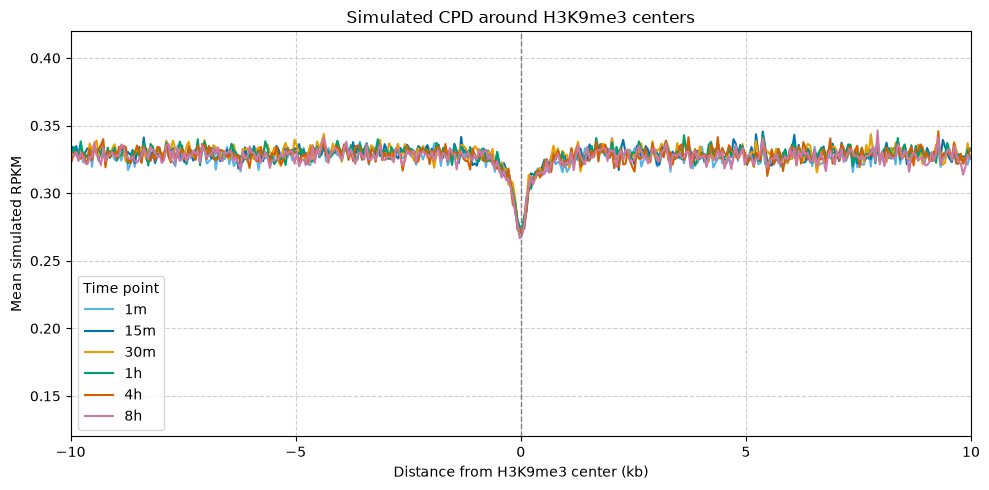

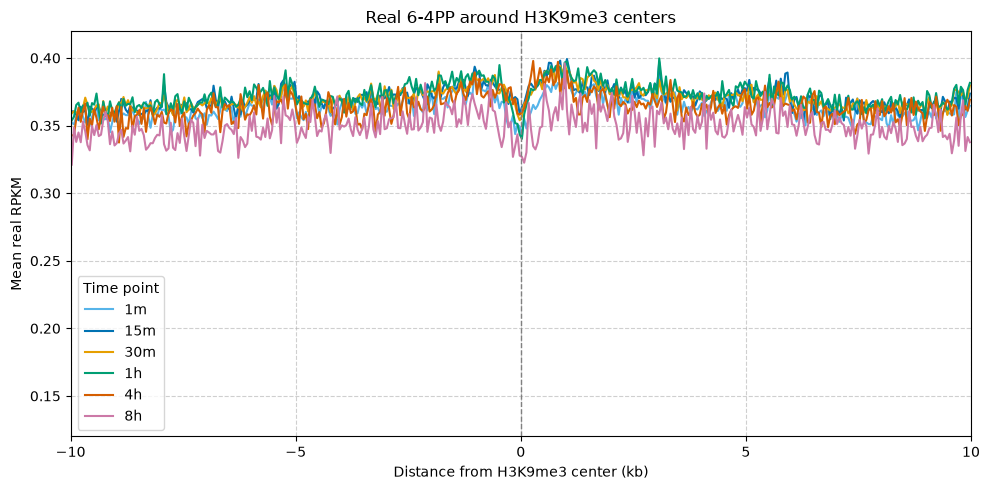

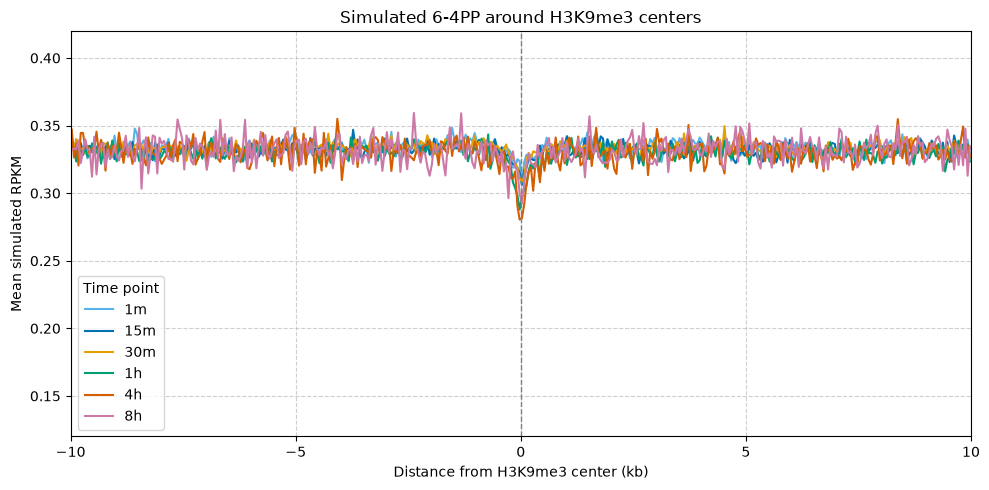

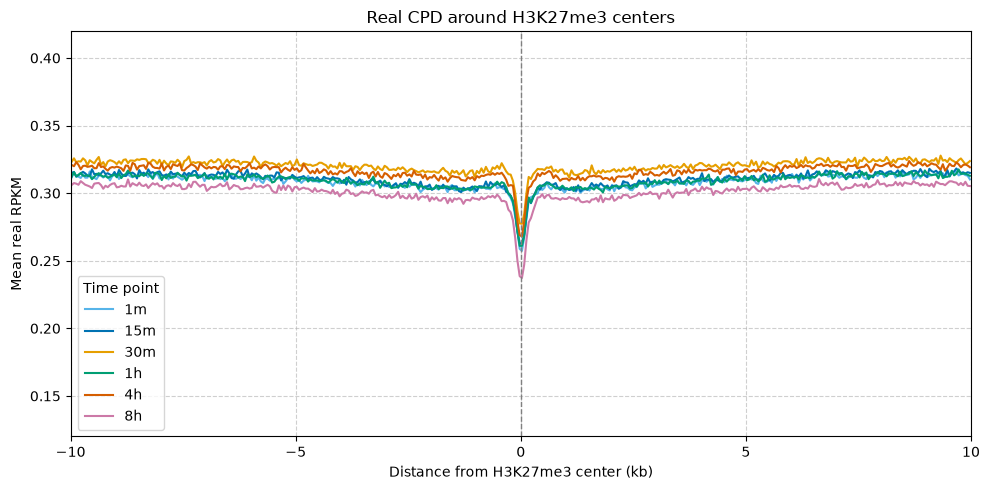

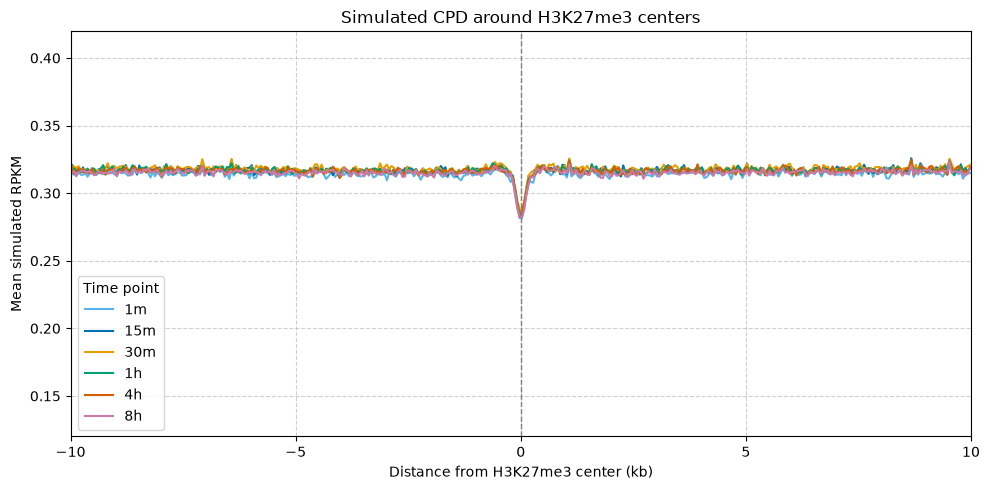

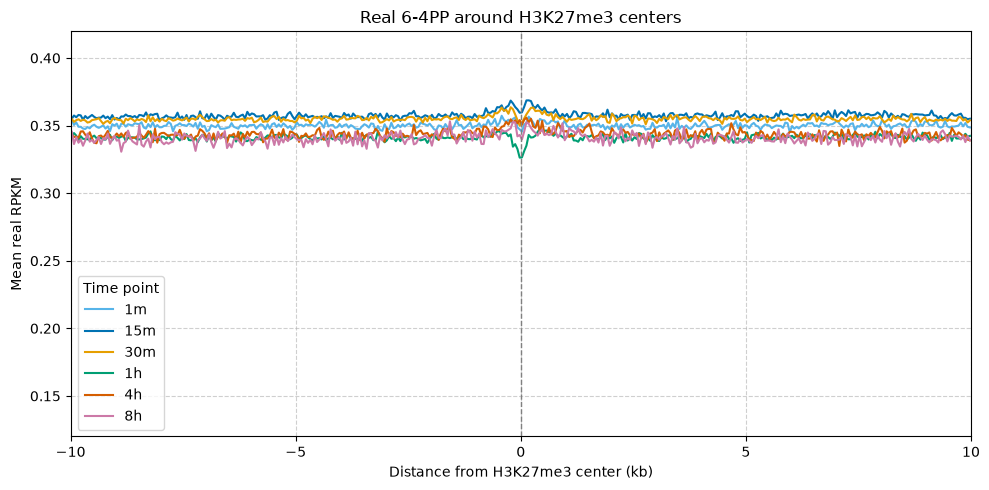

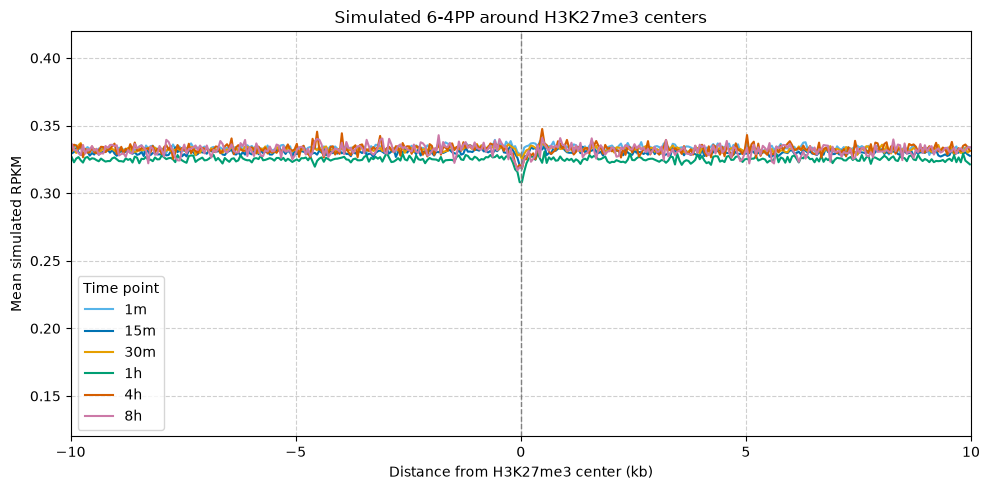

In [18]:
# If the summary cell was skipped, build summary from the small saved TSV files.
if 'summary' not in globals():
    tables = []
    for region in REGIONS:
        for damage in DAMAGES:
            for time in TIME_POINTS:
                table = pd.read_csv(existing_mean_path(region, damage, time), sep='\t')
                table.insert(0, 'time', time)
                table.insert(0, 'damage', damage)
                table.insert(0, 'region', region)
                table['distance_kb'] = -10 + (table['window'] - 0.5) * (20 / NUMBER_OF_WINDOWS)
                tables.append(table)
    summary = pd.concat(tables, ignore_index=True)
    summary.to_csv(
        OUTPUT_DIR / 'all_regions_direct_rpkm_summary.tsv',
        sep='\t',
        index=False,
    )

RAW_Y_MIN = 0.12
RAW_Y_MAX = summary[['mean_real_rpkm', 'mean_sim_rpkm']].max().max() * 1.05

for region in REGIONS:
    for damage in DAMAGES:
        selected = summary[(summary['region'] == region) & (summary['damage'] == damage)]

        for kind, column, label in [
            ('real', 'mean_real_rpkm', 'Real'),
            ('sim', 'mean_sim_rpkm', 'Simulated'),
        ]:
            fig, ax = plt.subplots(figsize=(10, 5))
            for time in TIME_POINTS:
                values = selected[selected['time'] == time].sort_values('window')
                ax.plot(values['distance_kb'], values[column], color=COLORS[time], label=time)

            ax.axvline(0, color='gray', linestyle='--', linewidth=1)
            ax.set_xlim(-10, 10)
            ax.set_ylim(RAW_Y_MIN, RAW_Y_MAX)
            ax.set_xticks([-10, -5, 0, 5, 10])
            ax.set_xlabel(f'Distance from {region} center (kb)')
            ax.set_ylabel(f'Mean {label.lower()} RPKM')
            ax.set_title(f'{label} {TITLES[damage]} around {region} centers')
            ax.grid(True, linestyle='--', alpha=0.6)
            ax.legend(title='Time point')
            fig.tight_layout()
            fig.savefig(
                OUTPUT_DIR / f'{region}_{damage}_all_timepoints_mean_{kind}_rpkm.png',
                dpi=300,
                bbox_inches='tight',
            )
            plt.show()
            plt.close(fig)


## Real/Sim ratio plots

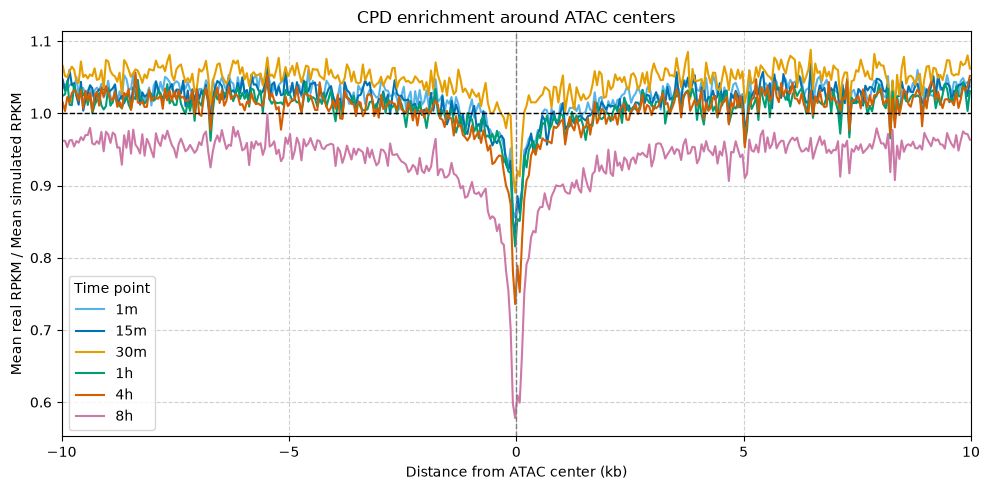

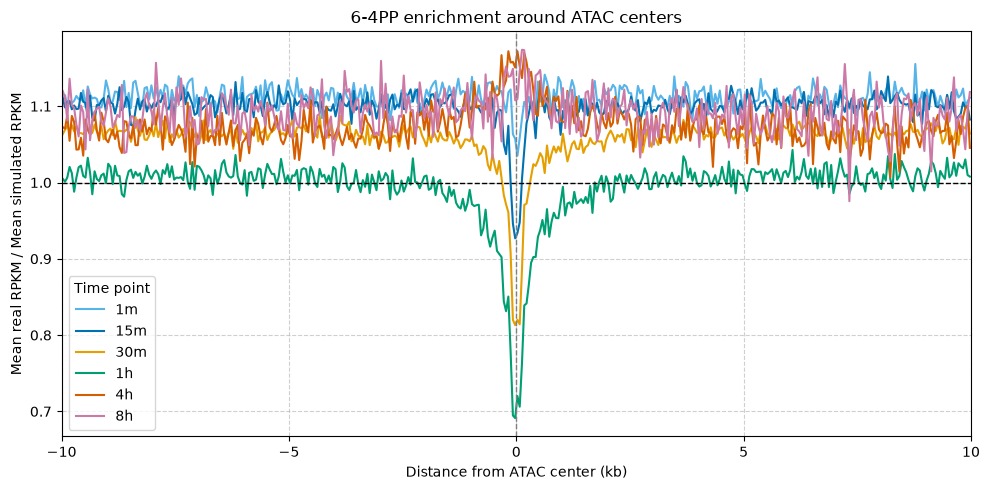

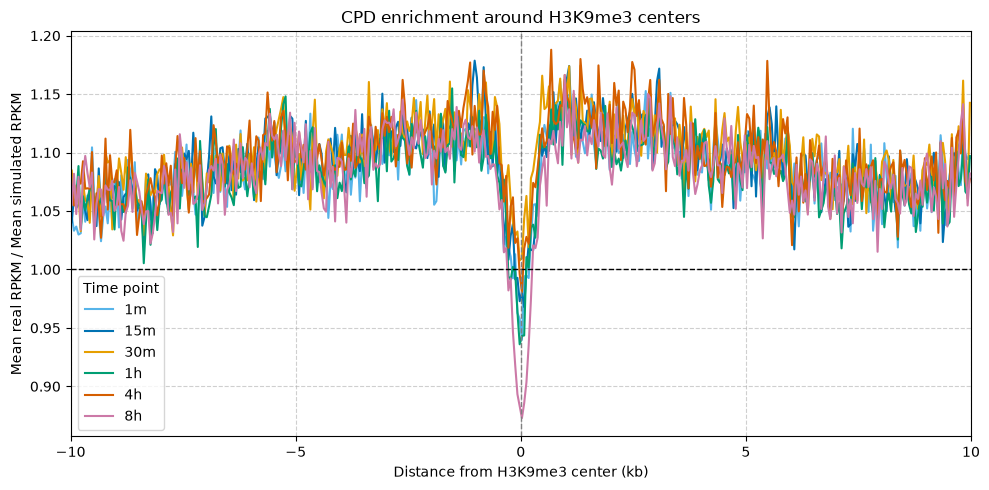

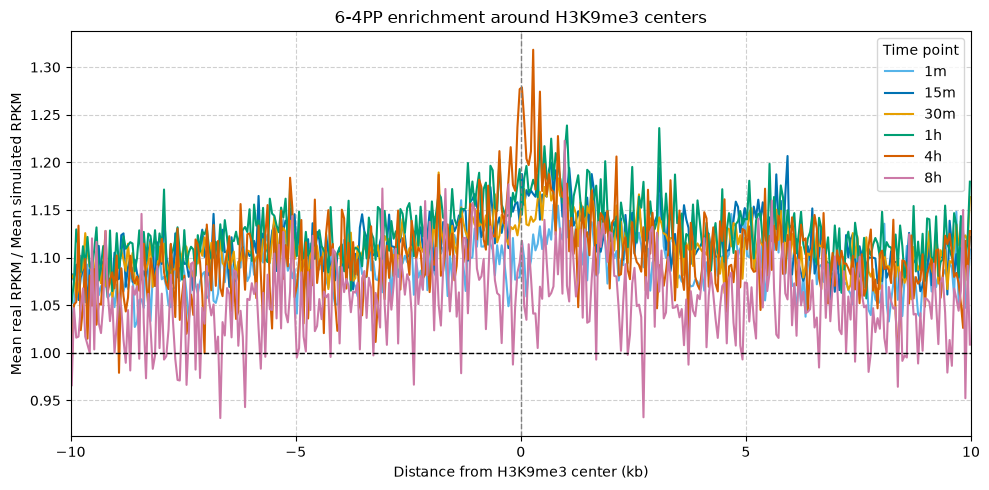

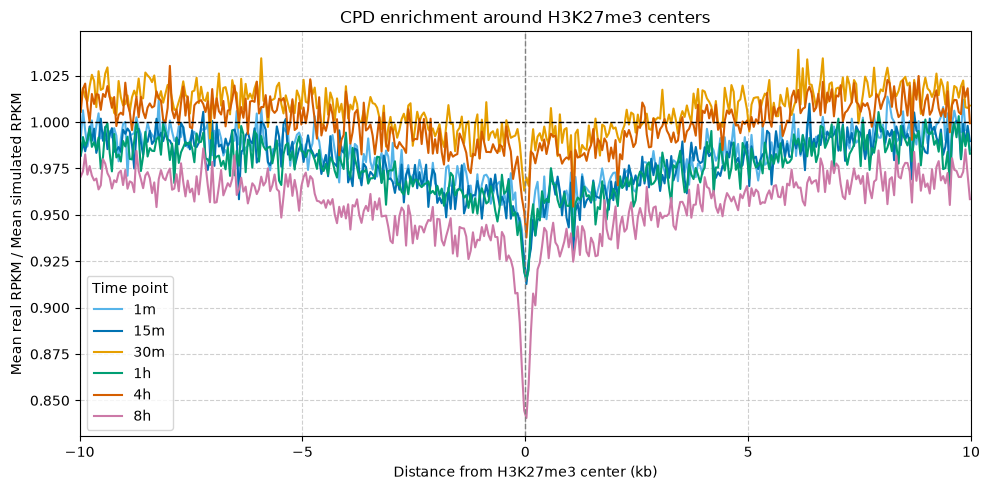

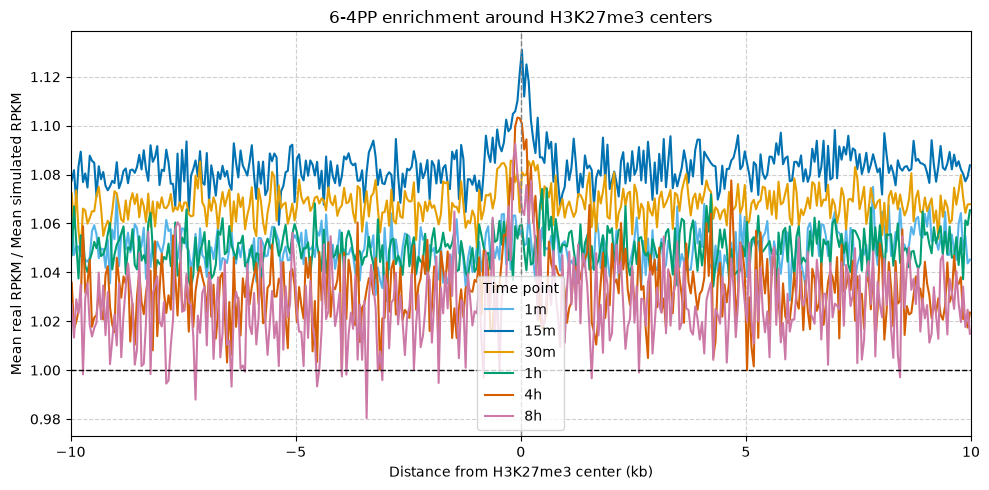

In [17]:
for region in REGIONS:
    for damage in DAMAGES:
        selected = summary[(summary['region'] == region) & (summary['damage'] == damage)]
        fig, ax = plt.subplots(figsize=(10, 5))

        for time in TIME_POINTS:
            values = selected[selected['time'] == time].sort_values('window')
            ax.plot(values['distance_kb'], values['real_sim_ratio'], color=COLORS[time], label=time)

        ax.axhline(1, color='black', linestyle='--', linewidth=1)
        ax.axvline(0, color='gray', linestyle='--', linewidth=1)
        ax.set_xlim(-10, 10)
        ax.set_xticks([-10, -5, 0, 5, 10])
        ax.set_xlabel(f'Distance from {region} center (kb)')
        ax.set_ylabel('Mean real RPKM / Mean simulated RPKM')
        ax.set_title(f'{TITLES[damage]} enrichment around {region} centers')
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend(title='Time point')
        fig.tight_layout()
        fig.savefig(OUTPUT_DIR / f'{region}_{damage}_all_timepoints_real_sim_ratio.png', dpi=300)
        plt.show()
        plt.close(fig)


## Baseline-normalized Real/Sim ratio plots

In [ ]:
for region in REGIONS:
    for damage in DAMAGES:
        selected = summary[(summary['region'] == region) & (summary['damage'] == damage)]
        fig, ax = plt.subplots(figsize=(10, 5))

        for time in TIME_POINTS:
            values = selected[selected['time'] == time].sort_values('window').copy()
            baseline_mask = (
                ((values['distance_kb'] >= -10) & (values['distance_kb'] <= -6))
                | ((values['distance_kb'] >= 6) & (values['distance_kb'] <= 10))
            )
            baseline = values.loc[baseline_mask, 'real_sim_ratio'].mean()
            normalized = values['real_sim_ratio'] / baseline
            ax.plot(values['distance_kb'], normalized, color=COLORS[time], label=time)

        ax.axhline(1, color='black', linestyle='--', linewidth=1)
        ax.axvline(0, color='gray', linestyle='--', linewidth=1)
        ax.set_xlim(-10, 10)
        ax.set_xticks([-10, -5, 0, 5, 10])
        ax.set_xlabel(f'Distance from {region} center (kb)')
        ax.set_ylabel('Baseline-normalized real/sim ratio')
        ax.set_title(f'{TITLES[damage]} enrichment around {region} centers (6–10 kb baseline)')
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend(title='Time point')
        fig.tight_layout()
        fig.savefig(OUTPUT_DIR / f'{region}_{damage}_all_timepoints_baseline_normalized.png', dpi=300)
        plt.show()
        plt.close(fig)
